# Norman GI Precision@10 Experiment

Precision@10 analysis on Norman payload results across multiple models, using GI truth labels built from the raw Norman truth dataset.

In [7]:
from __future__ import annotations

import importlib
from pathlib import Path

from IPython.display import Image, display

repo_root = Path.cwd().resolve()
while not ((repo_root / "scripts").exists() and (repo_root / "configs").exists()):
    if repo_root.parent == repo_root:
        raise FileNotFoundError("Could not locate repo root containing scripts/ and configs/")
    repo_root = repo_root.parent

import sys
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))
if str(repo_root / "src") not in sys.path:
    sys.path.insert(0, str(repo_root / "src"))

import scripts.trishift.analysis.norman_gi_precision_experiment as norman_gi_precision_experiment
importlib.reload(norman_gi_precision_experiment)

run_norman_gi_precision_experiment = norman_gi_precision_experiment.run_norman_gi_precision_experiment
repo_root

WindowsPath('E:/CODE/trishift')

In [8]:
dataset = "norman"
models = ["trishift_nearest", "scouter", "gears", "genepert", "scgpt"]
split_ids = "1,2,3,4,5"
truth_labels_path = repo_root / "artifacts" / "analysis" / "norman_gi_truth" / "norman_gi_truth_labels.csv"
out_root = repo_root / "artifacts" / "analysis" / "norman_gi_precision_experiment"
top_k = 10
dataset, models, split_ids, truth_labels_path, out_root, top_k

('norman',
 ['trishift_nearest', 'scouter', 'gears', 'genepert', 'scgpt'],
 '1,2,3,4,5',
 WindowsPath('E:/CODE/trishift/artifacts/analysis/norman_gi_truth/norman_gi_truth_labels.csv'),
 WindowsPath('E:/CODE/trishift/artifacts/analysis/norman_gi_precision_experiment'),
 10)

In [9]:
result = run_norman_gi_precision_experiment(
    dataset=dataset,
    models=models,
    split_ids=split_ids,
    truth_labels_path=truth_labels_path,
    out_root=out_root,
    top_k=top_k,
)
print(f"out_dir: {result['out_dir']}")

E:\CODE\trishift\scripts\trishift\analysis\norman_gi_precision_experiment.py:373: RuntimeWarning: [norman_gi_precision] skip model=scgpt: payload unavailable
  "gi_types": GI_TYPE_ORDER,


out_dir: E:\CODE\trishift\artifacts\analysis\norman_gi_precision_experiment


In [10]:
display(result["summary_df"])
display(result["coverage_df"])
display(result["skipped_df"].head())

,index,model_name,gi_type,gi_label,metric_name,rank_direction,precision_at_10_mean,precision_at_10_std,precision_at_10_min,precision_at_10_max,...,positive_truth_n_mean,positive_truth_n_std,positive_truth_n_min,positive_truth_n_max,effective_k_mean,effective_k_std,effective_k_min,effective_k_max,valid_split_n,attempted_split_n
0,0,gears,balanced_synergy,Balanced Synergy,mag,max,0.1250,NaN,0.125,0.125,...,0.2,0.447214,0,1,3.6,2.880972,1,8,1,5
1,1,gears,dominant_epistasis,Dominant Epistasis,dominance,max,0.2500,NaN,0.250,0.250,...,0.4,0.894427,0,2,3.6,2.880972,1,8,1,5
2,2,gears,epistasis,Epistasis,eq_contr,min,0.4375,0.088388,0.375,0.500,...,0.8,1.303840,0,3,3.6,2.880972,1,8,2,5
3,3,gears,neomorphic,Neomorphism,corr_fit,min,0.2750,0.198431,0.125,0.500,...,0.6,0.547723,0,1,3.6,2.880972,1,8,3,5
4,4,gears,redundancy,Redundancy,dcor,max,0.3250,0.106066,0.250,0.400,...,0.8,1.095445,0,2,3.6,2.880972,1,8,2,5
5,5,gears,strong_interaction,Strong Interaction,mag,max,NaN,NaN,NaN,NaN,...,0.0,0.000000,0,0,3.6,2.880972,1,8,0,5
6,6,gears,suppressor,Suppression,mag,min,0.6250,0.530330,0.250,1.000,...,0.8,1.095445,0,2,3.6,2.880972,1,8,2,5
7,7,gears,synergy,Synergy,mag,max,0.1625,0.053033,0.125,0.200,...,0.4,0.547723,0,1,3.6,2.880972,1,8,2,5
8,8,genepert,balanced_synergy,Balanced Synergy,mag,max,NaN,NaN,NaN,NaN,...,0.0,0.000000,0,0,0.2,0.447214,0,1,0,5
9,9,genepert,dominant_epistasis,Dominant Epistasis,dominance,max,NaN,NaN,NaN,NaN,...,0.0,0.000000,0,0,0.2,0.447214,0,1,0,5


,index,model_name,gi_type,gi_label,coverage_n_mean,coverage_n_min,coverage_n_max,positive_truth_n_mean,positive_truth_n_min,positive_truth_n_max,effective_k_mean,effective_k_min,effective_k_max
0,0,gears,balanced_synergy,Balanced Synergy,3.6,1,8,0.2,0,1,3.6,1,8
1,1,gears,dominant_epistasis,Dominant Epistasis,3.6,1,8,0.4,0,2,3.6,1,8
2,2,gears,epistasis,Epistasis,3.6,1,8,0.8,0,3,3.6,1,8
3,3,gears,neomorphic,Neomorphism,3.6,1,8,0.6,0,1,3.6,1,8
4,4,gears,redundancy,Redundancy,3.6,1,8,0.8,0,2,3.6,1,8
5,5,gears,strong_interaction,Strong Interaction,3.6,1,8,0.0,0,0,3.6,1,8
6,6,gears,suppressor,Suppression,3.6,1,8,0.8,0,2,3.6,1,8
7,7,gears,synergy,Synergy,3.6,1,8,0.4,0,1,3.6,1,8
8,8,genepert,balanced_synergy,Balanced Synergy,0.2,0,1,0.0,0,0,0.2,0,1
9,9,genepert,dominant_epistasis,Dominant Epistasis,0.2,0,1,0.0,0,0,0.2,0,1


,gi_type,model_name,split_id,condition,skip_reason
0,,trishift_nearest,1,AHR+FEV,missing single perturbation: AHR+ctrl
1,,trishift_nearest,1,AHR+KLF1,missing single perturbation: AHR+ctrl
2,,trishift_nearest,1,BCL2L11+TGFBR2,missing single perturbation: BCL2L11+ctrl
3,,trishift_nearest,1,C19orf26+TGFBR2,missing single perturbation: C19orf26+ctrl
4,,trishift_nearest,1,C3orf72+FOXL2,missing single perturbation: C3orf72+ctrl


E:\CODE\trishift\artifacts\analysis\norman_gi_precision_experiment\norman_gi_precision_barplot.png


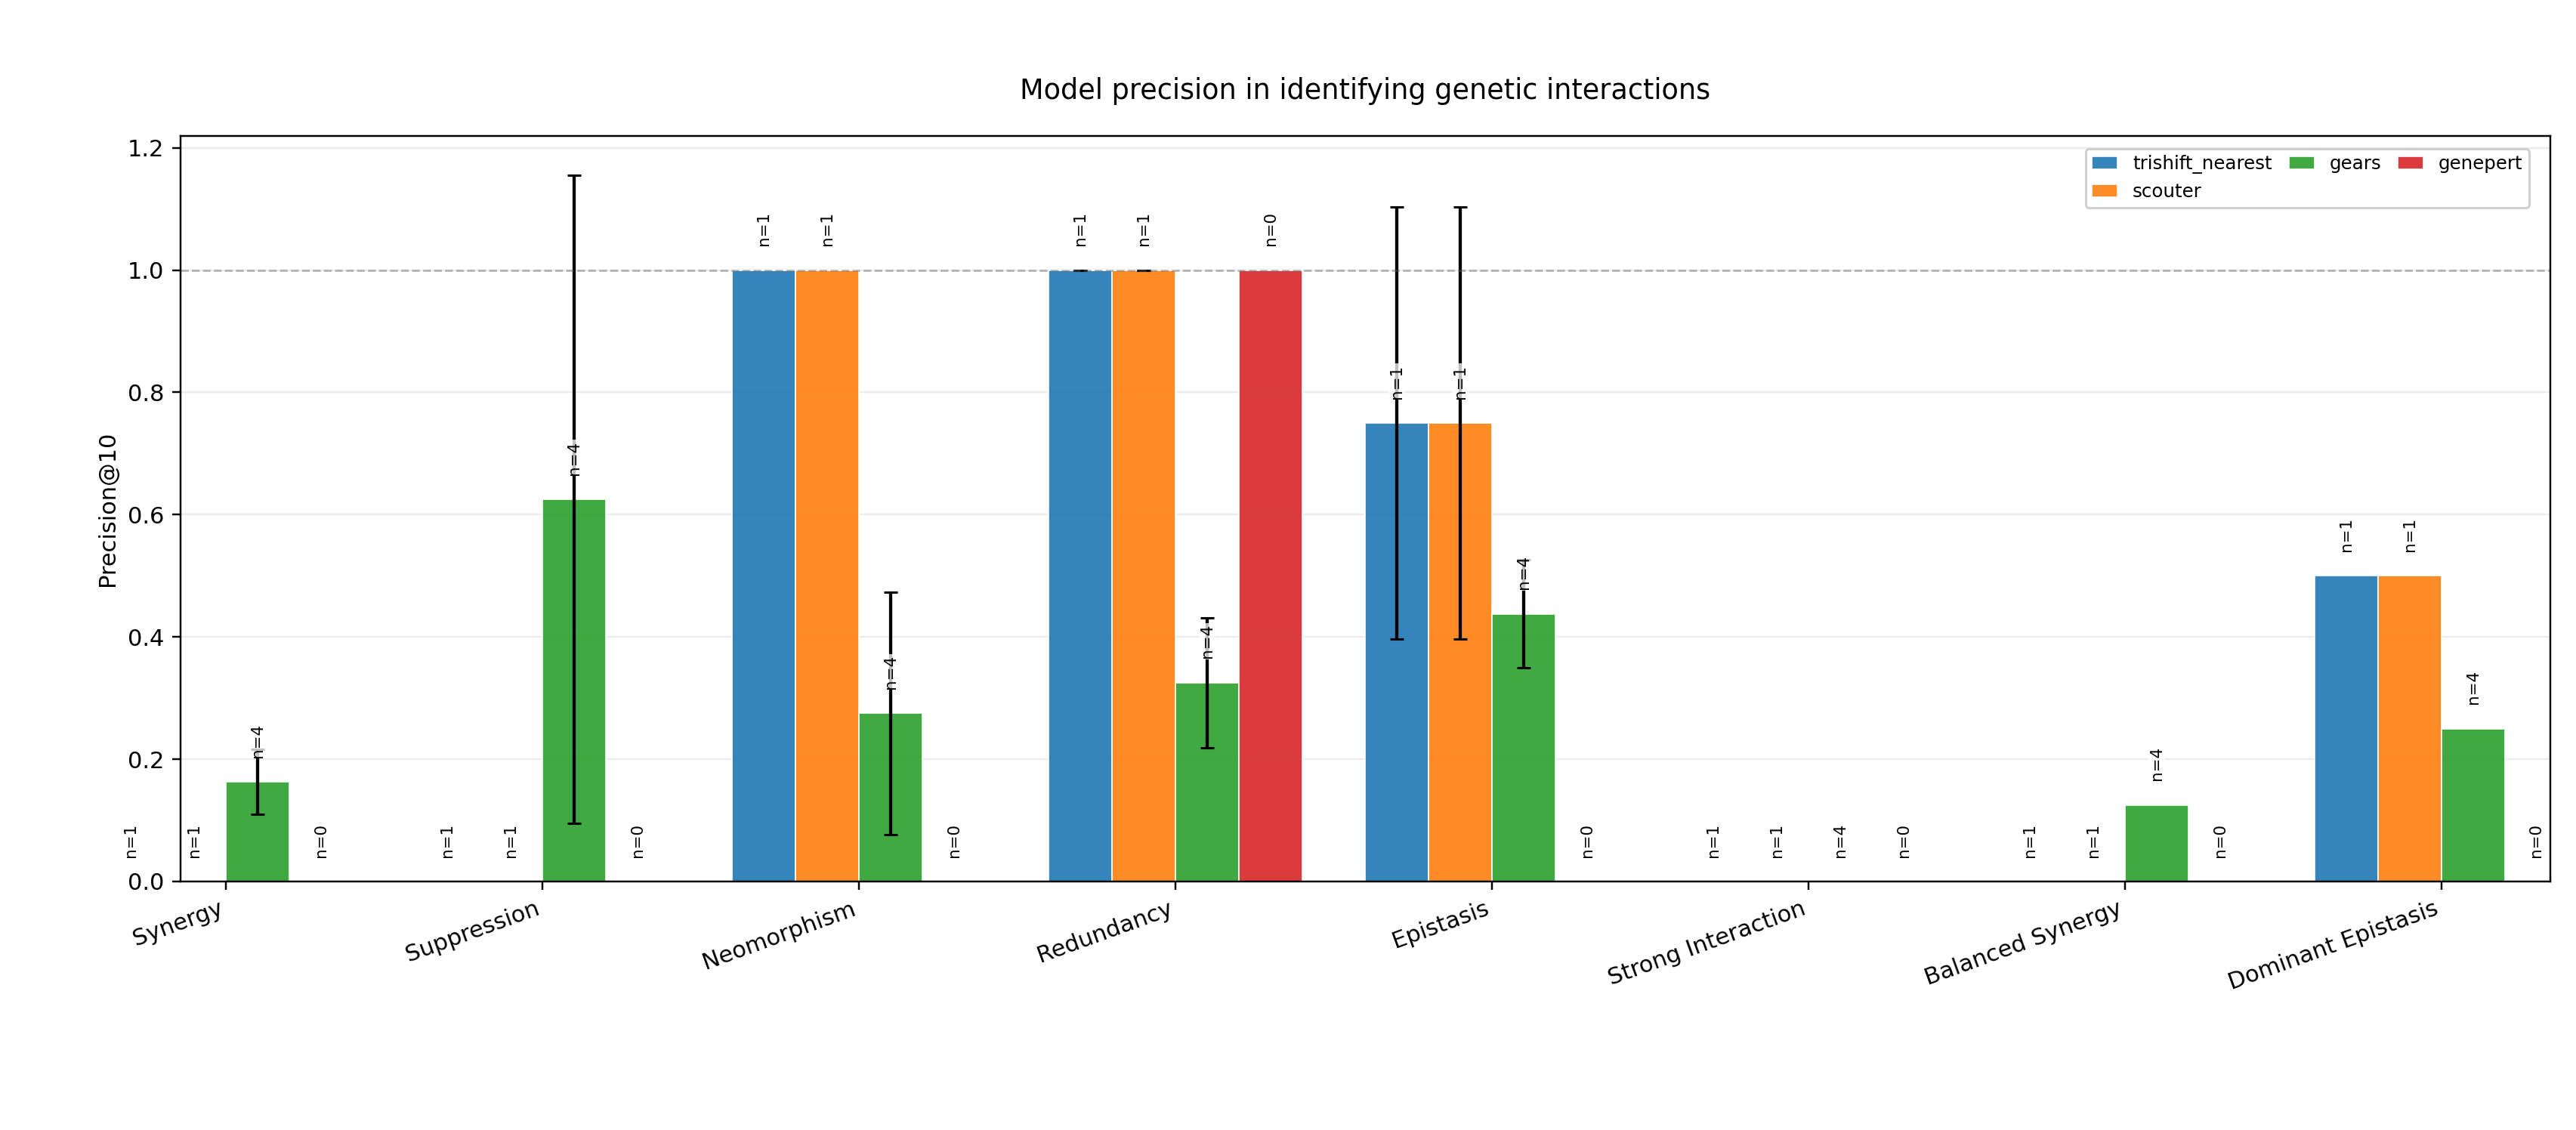

E:\CODE\trishift\artifacts\analysis\norman_gi_precision_experiment\norman_gi_precision_coverage_barplot.png


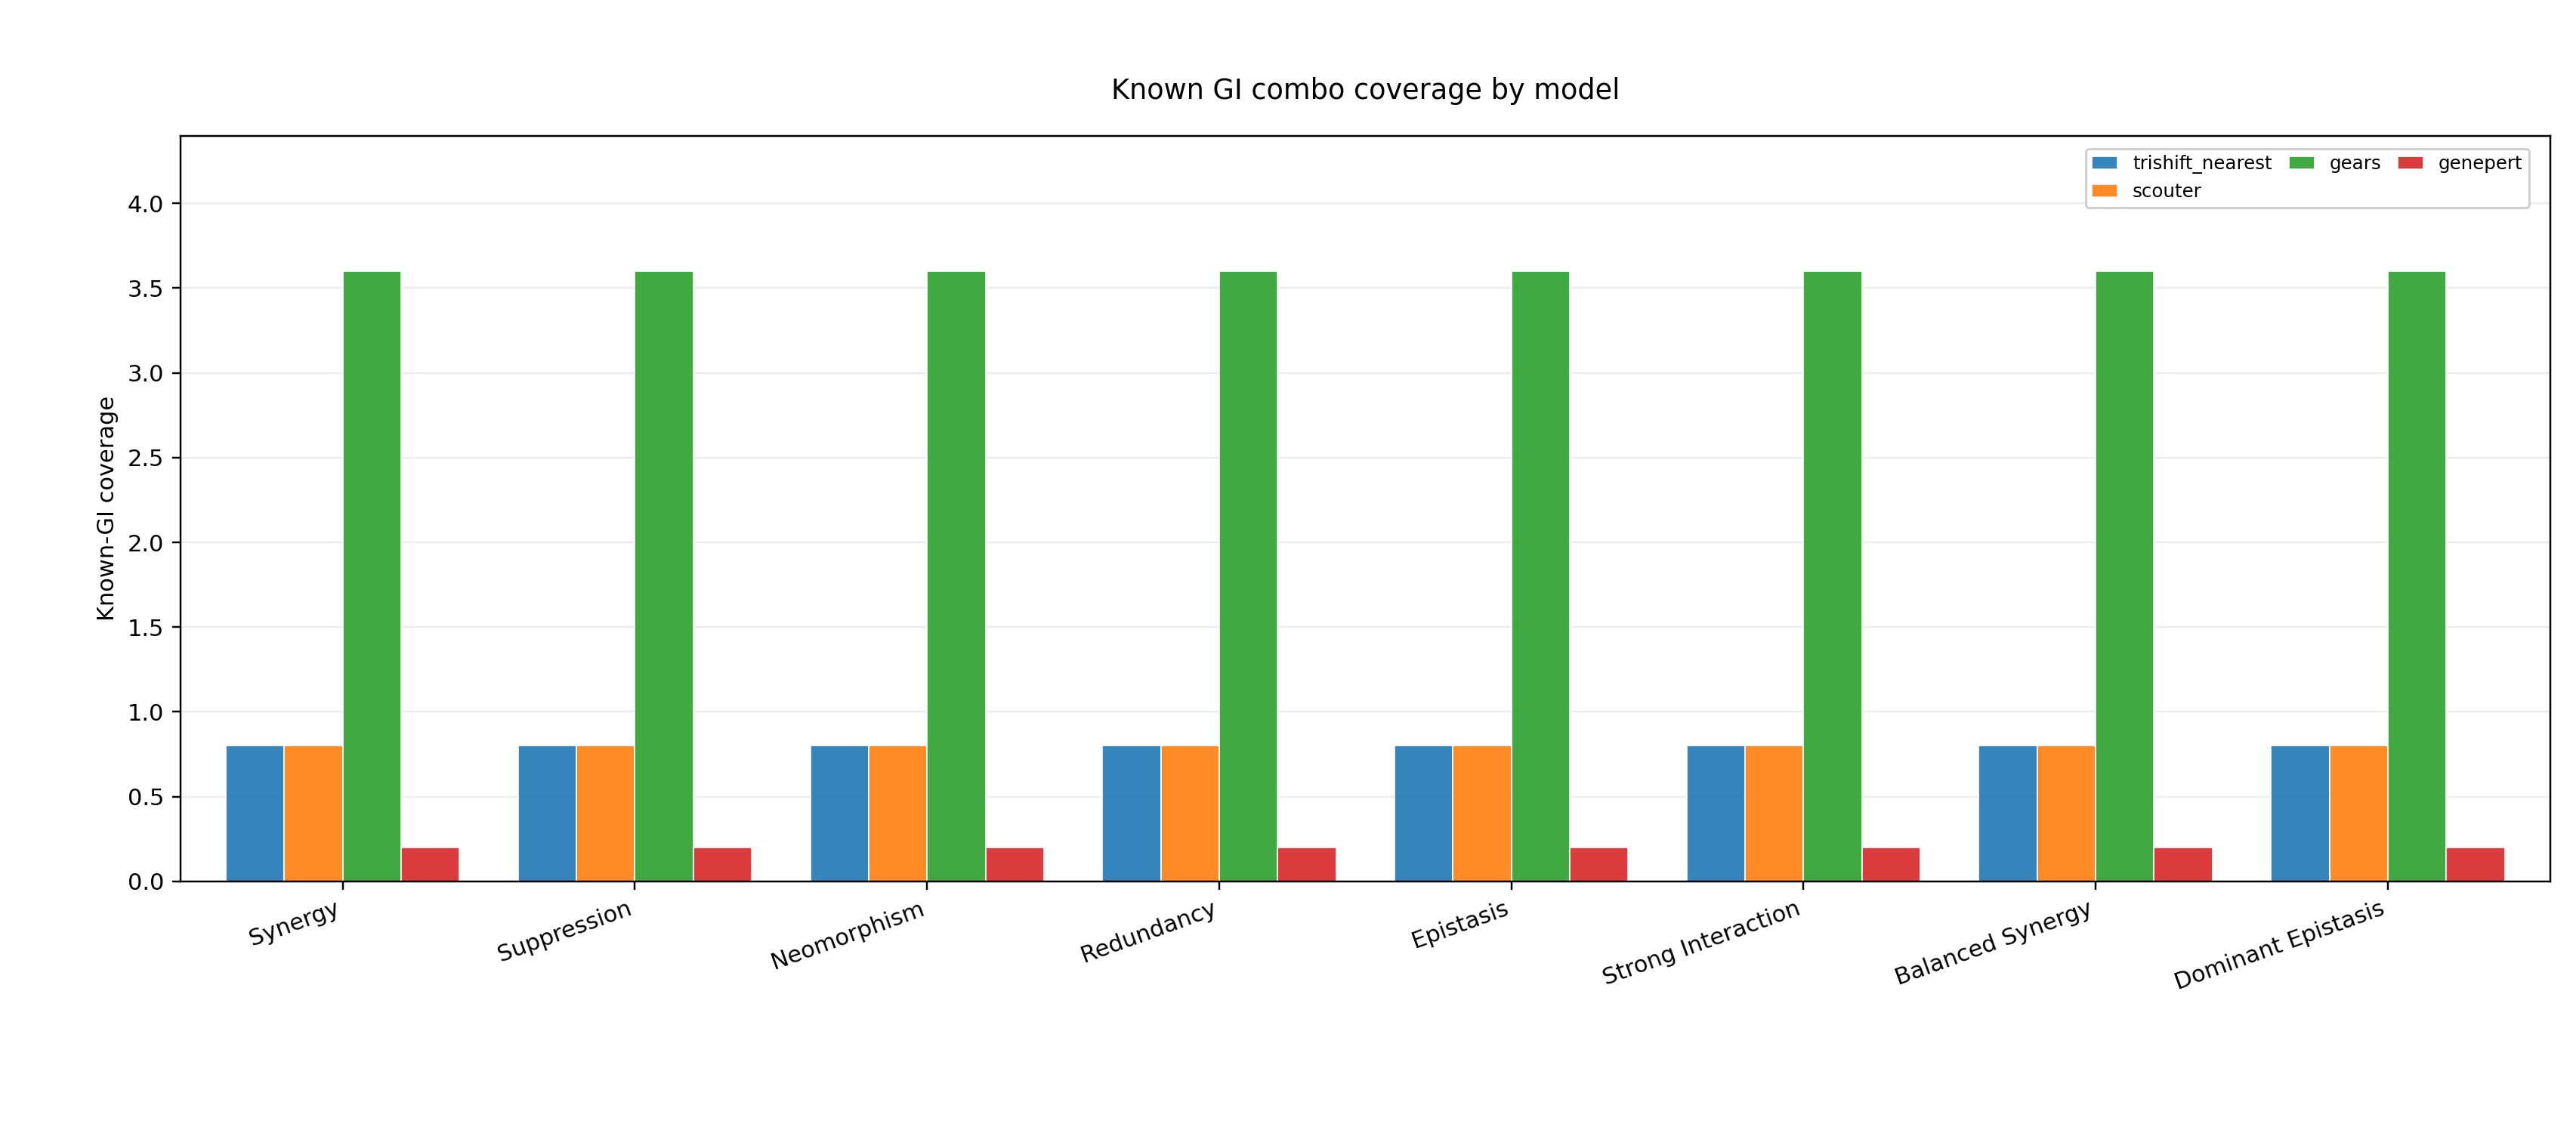

In [11]:
for name in [
    "norman_gi_precision_barplot.png",
    "norman_gi_precision_coverage_barplot.png",
]:
    path = result["out_dir"] / name
    print(path)
    display(Image(filename=str(path)))

In [12]:
sorted(str(p) for p in result["out_dir"].glob("*"))

['E:\\CODE\\trishift\\artifacts\\analysis\\norman_gi_precision_experiment\\norman_gi_precision_barplot.png',
 'E:\\CODE\\trishift\\artifacts\\analysis\\norman_gi_precision_experiment\\norman_gi_precision_coverage.csv',
 'E:\\CODE\\trishift\\artifacts\\analysis\\norman_gi_precision_experiment\\norman_gi_precision_coverage_barplot.png',
 'E:\\CODE\\trishift\\artifacts\\analysis\\norman_gi_precision_experiment\\norman_gi_precision_per_split.csv',
 'E:\\CODE\\trishift\\artifacts\\analysis\\norman_gi_precision_experiment\\norman_gi_precision_skipped.csv',
 'E:\\CODE\\trishift\\artifacts\\analysis\\norman_gi_precision_experiment\\norman_gi_precision_summary.csv',
 'E:\\CODE\\trishift\\artifacts\\analysis\\norman_gi_precision_experiment\\run_meta.json']